In [5]:
# ================================================================
# ROOFTOP POLYGON EXTRACTION — Complete Google Colab Notebook
# Imphal Rooftop Project
# ================================================================

# ----------------------------------------------------------------
# CELL 1 — Install dependencies
# ----------------------------------------------------------------
!pip install rasterio opencv-python-headless shapely geopandas fiona -q

import rasterio
import rasterio.transform
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from shapely.geometry import Polygon, MultiPolygon
from shapely.ops import unary_union
from shapely.validation import make_valid
import geopandas as gpd
import os
import json
from google.colab import drive, files
from IPython.display import display, HTML

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [7]:
# ----------------------------------------------------------------
# CELL 2 — Mount Google Drive
# ----------------------------------------------------------------
drive.mount('/content/drive')

# ---- CONFIGURE YOUR PATHS HERE ---------------------------------
RGB_PATH   = "imphal_rgb.tif"
OUTPUT_DIR = "/content/drive/MyDrive/Imphal_Rooftop_Project/outputs/"
# ----------------------------------------------------------------

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✅ Output directory ready: {OUTPUT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Output directory ready: /content/drive/MyDrive/Imphal_Rooftop_Project/outputs/


Bands      : 3
Dtype      : float64
Shape      : (3, 1337, 1559)
CRS        : EPSG:4326
Transform  : | 0.00, 0.00, 93.88|
| 0.00,-0.00, 24.86|
| 0.00, 0.00, 1.00|
Bounds     : BoundingBox(left=93.8799659028936, bottom=24.73996225076527, right=94.02001325568783, top=24.86006700425205)


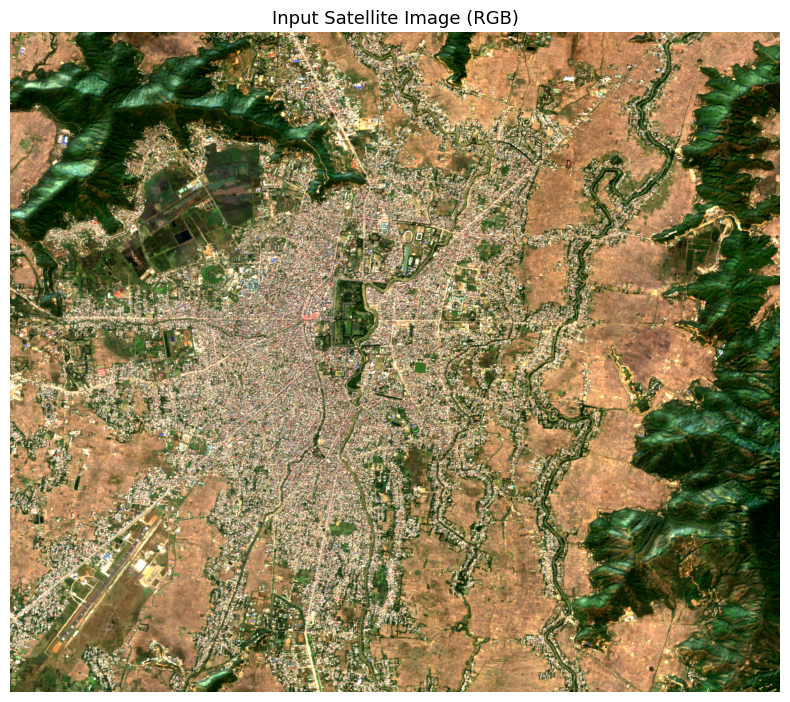

✅ Image loaded successfully


In [8]:
# ----------------------------------------------------------------
# CELL 3 — Load & inspect image
# ----------------------------------------------------------------
with rasterio.open(RGB_PATH) as src:
    img_data  = src.read()           # all bands
    transform = src.transform
    crs       = src.crs
    profile   = src.profile
    bounds    = src.bounds
    n_bands   = src.count
    dtype     = src.dtypes[0]

print(f"Bands      : {n_bands}")
print(f"Dtype      : {dtype}")
print(f"Shape      : {img_data.shape}")
print(f"CRS        : {crs}")
print(f"Transform  : {transform}")
print(f"Bounds     : {bounds}")

# Pick first 3 bands as RGB
rgb_raw = img_data[:3]
img = np.transpose(rgb_raw, (1, 2, 0)).astype(np.float32)

# Robust normalisation (2nd–98th percentile stretch)
p2, p98 = np.percentile(img, 2), np.percentile(img, 98)
img = np.clip((img - p2) / (p98 - p2 + 1e-8), 0, 1)
img_uint8 = (img * 255).astype(np.uint8)

plt.figure(figsize=(8, 8))
plt.imshow(img_uint8)
plt.title("Input Satellite Image (RGB)", fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "01_input_image.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Image loaded successfully")

Bands      : 3
Dtype      : float64
Shape      : (3, 1337, 1559)
CRS        : EPSG:4326
Transform  : | 0.00, 0.00, 93.88|
| 0.00,-0.00, 24.86|
| 0.00, 0.00, 1.00|
Bounds     : BoundingBox(left=93.8799659028936, bottom=24.73996225076527, right=94.02001325568783, top=24.86006700425205)


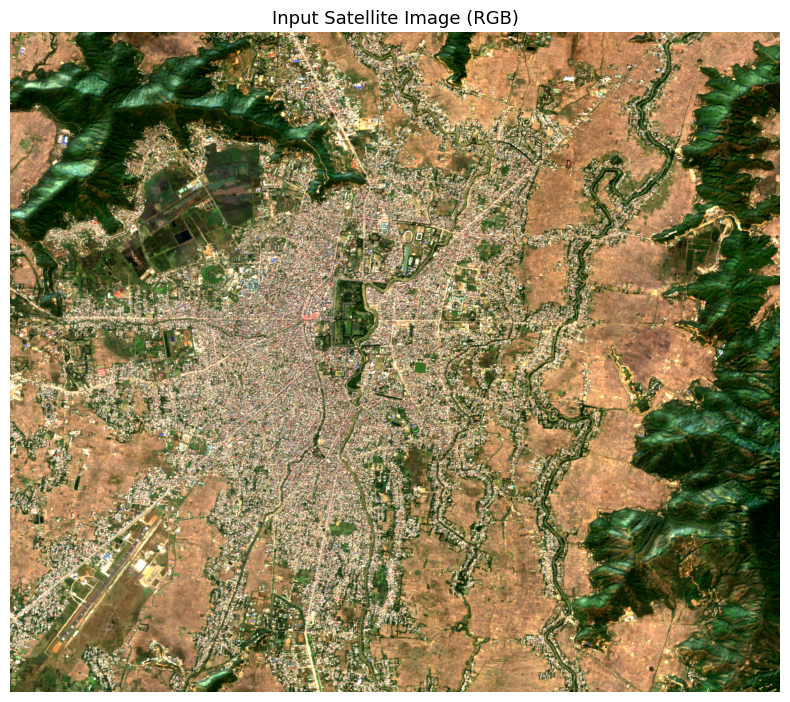

✅ Image loaded successfully


In [9]:
# ----------------------------------------------------------------
# CELL 3 — Load & inspect image
# ----------------------------------------------------------------
with rasterio.open(RGB_PATH) as src:
    img_data  = src.read()           # all bands
    transform = src.transform
    crs       = src.crs
    profile   = src.profile
    bounds    = src.bounds
    n_bands   = src.count
    dtype     = src.dtypes[0]

print(f"Bands      : {n_bands}")
print(f"Dtype      : {dtype}")
print(f"Shape      : {img_data.shape}")
print(f"CRS        : {crs}")
print(f"Transform  : {transform}")
print(f"Bounds     : {bounds}")

# Pick first 3 bands as RGB
rgb_raw = img_data[:3]
img = np.transpose(rgb_raw, (1, 2, 0)).astype(np.float32)

# Robust normalisation (2nd–98th percentile stretch)
p2, p98 = np.percentile(img, 2), np.percentile(img, 98)
img = np.clip((img - p2) / (p98 - p2 + 1e-8), 0, 1)
img_uint8 = (img * 255).astype(np.uint8)

plt.figure(figsize=(8, 8))
plt.imshow(img_uint8)
plt.title("Input Satellite Image (RGB)", fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "01_input_image.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Image loaded successfully")

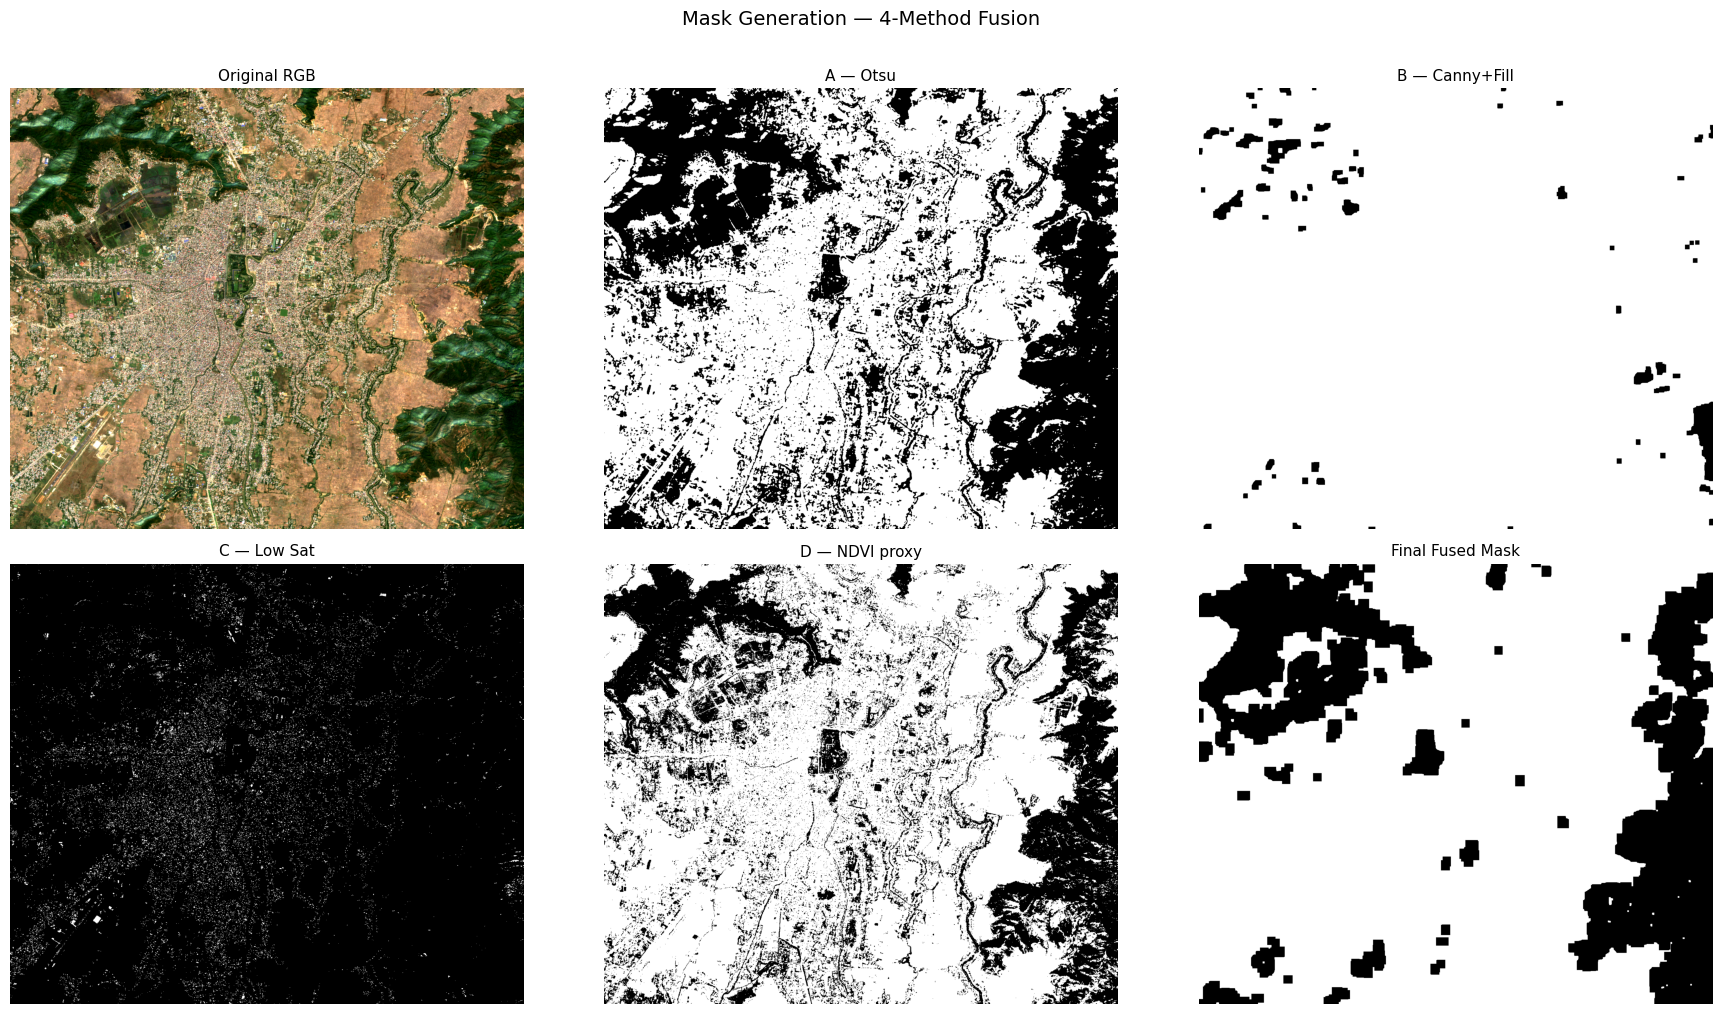

✅ Mask created — non-zero pixels: 1531591


In [10]:
# ----------------------------------------------------------------
# CELL 4 — Build rooftop mask  (multi-method fusion)
# ----------------------------------------------------------------

gray    = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# --- Method A: Otsu adaptive threshold -------------------------
_, mask_otsu = cv2.threshold(
    blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# --- Method B: Canny edges → closed filled regions -------------
edges  = cv2.Canny(blurred, 30, 100)
k5     = np.ones((5, 5), np.uint8)
filled = cv2.dilate(edges, k5, iterations=2)
filled = cv2.morphologyEx(filled, cv2.MORPH_CLOSE, k5, iterations=3)

# --- Method C: Low HSV saturation (rooftops = low sat) ---------
hsv = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2HSV)
_, mask_sat = cv2.threshold(
    hsv[:, :, 1], 40, 255, cv2.THRESH_BINARY_INV
)

# --- Method D: NDVI proxy (rooftops are not vegetation) --------
# uses Red & NIR-proxy (green channel as fallback if no NIR)
red   = img_uint8[:, :, 0].astype(np.float32)
green = img_uint8[:, :, 1].astype(np.float32)
ndvi_proxy = (green - red) / (green + red + 1e-8)
mask_ndvi  = np.where(ndvi_proxy < 0.05, 255, 0).astype(np.uint8)

# --- Majority vote (≥3 of 4 methods agree) ---------------------
vote = (
    mask_otsu.astype(np.uint16) +
    filled.astype(np.uint16)    +
    mask_sat.astype(np.uint16)  +
    mask_ndvi.astype(np.uint16)
) // 255

mask_raw = np.where(vote >= 3, 255, 0).astype(np.uint8)

# --- Morphological cleanup -------------------------------------
k3 = np.ones((3, 3), np.uint8)
k9 = np.ones((9, 9), np.uint8)
mask_clean = cv2.morphologyEx(mask_raw, cv2.MORPH_OPEN,  k3, iterations=2)
mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, k9, iterations=3)
mask_final = mask_clean

# --- Visualise all masks ---------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
pairs = [
    ("Original RGB",      img_uint8,  None),
    ("A — Otsu",          mask_otsu,  "gray"),
    ("B — Canny+Fill",    filled,     "gray"),
    ("C — Low Sat",       mask_sat,   "gray"),
    ("D — NDVI proxy",    mask_ndvi,  "gray"),
    ("Final Fused Mask",  mask_final, "gray"),
]
for ax, (title, im, cmap) in zip(axes.flat, pairs):
    ax.imshow(im, cmap=cmap)
    ax.set_title(title, fontsize=11)
    ax.axis("off")
plt.suptitle("Mask Generation — 4-Method Fusion", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "02_mask_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Mask created — non-zero pixels: {np.count_nonzero(mask_final)}")

In [11]:
# ----------------------------------------------------------------
# CELL 5 — Extract & refine polygons
# ----------------------------------------------------------------

# ---- TUNING PARAMETERS (adjust to your image) -----------------
MIN_AREA_PX    = 300      # minimum blob area in pixels
MAX_AREA_PX    = 60000    # maximum blob area in pixels
SIMPLIFY_EPS   = 0.015    # Douglas-Peucker (fraction of perimeter)
SOLIDITY_MIN   = 0.50     # reject very irregular blobs (0–1)
ASPECT_MAX     = 6.0      # reject very elongated blobs
# ---------------------------------------------------------------

contours, hierarchy = cv2.findContours(
    mask_final, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)
print(f"Raw contours found: {len(contours)}")

polygons    = []   # Shapely geo polygons
pixel_polys = []   # pixel-coord polygon points
stats_list  = []   # per-polygon attributes

rejected = {"too_small": 0, "too_large": 0, "low_solidity": 0,
            "aspect": 0, "invalid_geom": 0}

for cnt in contours:
    area = cv2.contourArea(cnt)

    if area < MIN_AREA_PX:
        rejected["too_small"] += 1
        continue
    if area > MAX_AREA_PX:
        rejected["too_large"] += 1
        continue

    # Solidity check
    hull     = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull)
    solidity  = area / (hull_area + 1e-8)
    if solidity < SOLIDITY_MIN:
        rejected["low_solidity"] += 1
        continue

    # Aspect ratio check
    x, y, w, h = cv2.boundingRect(cnt)
    aspect = max(w, h) / (min(w, h) + 1e-8)
    if aspect > ASPECT_MAX:
        rejected["aspect"] += 1
        continue

    # Simplify outline
    epsilon = SIMPLIFY_EPS * cv2.arcLength(cnt, True)
    approx  = cv2.approxPolyDP(cnt, epsilon, True)
    if len(approx) < 3:
        continue

    pts_px = [(int(pt[0][0]), int(pt[0][1])) for pt in approx]
    pixel_polys.append(pts_px)

    # Pixel → geo coordinates
    geo_coords = []
    for px, py in pts_px:
        lon, lat = rasterio.transform.xy(transform, py, px)
        geo_coords.append((lon, lat))

    poly = Polygon(geo_coords)
    if not poly.is_valid:
        poly = make_valid(poly)
    if poly.is_empty or not isinstance(poly, (Polygon, MultiPolygon)):
        rejected["invalid_geom"] += 1
        continue

    polygons.append(poly)
    stats_list.append({
        "area_px":   round(area, 1),
        "solidity":  round(solidity, 3),
        "aspect":    round(aspect, 2),
    })

print(f"\n✅ Valid polygons extracted : {len(polygons)}")
print(f"Rejected — too small       : {rejected['too_small']}")
print(f"Rejected — too large       : {rejected['too_large']}")
print(f"Rejected — low solidity    : {rejected['low_solidity']}")
print(f"Rejected — high aspect     : {rejected['aspect']}")
print(f"Rejected — invalid geom    : {rejected['invalid_geom']}")

Raw contours found: 29

✅ Valid polygons extracted : 6
Rejected — too small       : 20
Rejected — too large       : 1
Rejected — low solidity    : 2
Rejected — high aspect     : 0
Rejected — invalid geom    : 0


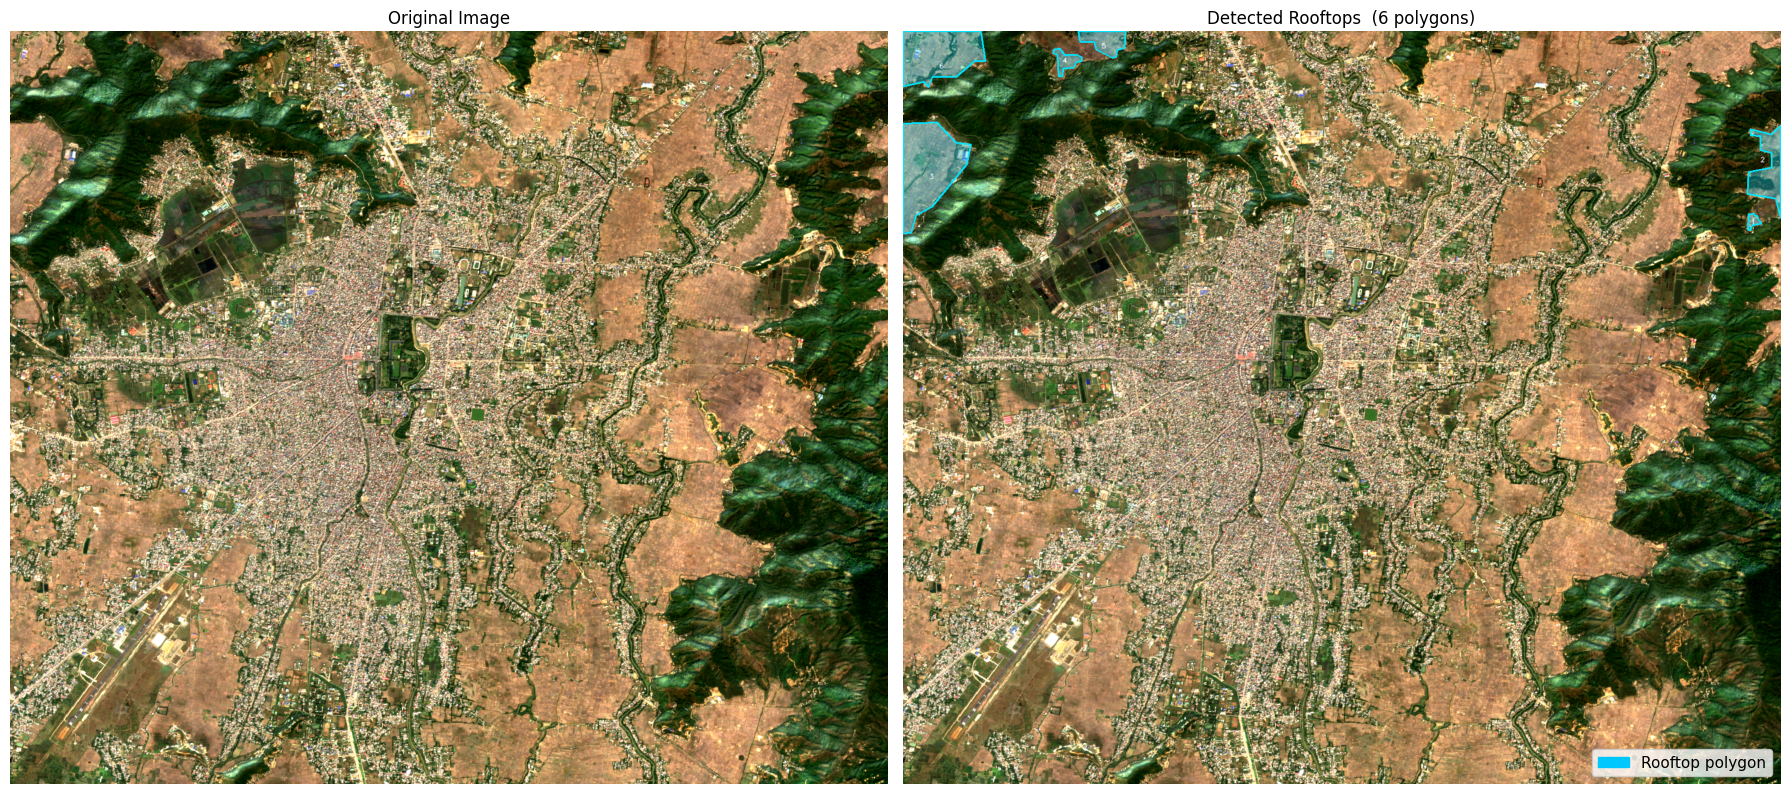

✅ Visualisation saved


In [12]:
# ----------------------------------------------------------------
# CELL 6 — Visualise polygons on satellite image
# ----------------------------------------------------------------

vis      = img_uint8.copy()
fill_img = img_uint8.copy()

for pts in pixel_polys:
    pts_arr = np.array(pts, dtype=np.int32)
    cv2.fillPoly(fill_img, [pts_arr], color=(0, 200, 255))

# Transparent fill blend
overlay = cv2.addWeighted(img_uint8, 0.65, fill_img, 0.35, 0)

# Draw outlines on top
for pts in pixel_polys:
    pts_arr = np.array(pts, dtype=np.int32)
    cv2.polylines(overlay, [pts_arr], isClosed=True,
                  color=(0, 230, 255), thickness=2)

# Centroid labels
for i, pts in enumerate(pixel_polys):
    arr    = np.array(pts)
    cx, cy = int(arr[:, 0].mean()), int(arr[:, 1].mean())
    cv2.putText(overlay, str(i + 1), (cx - 6, cy + 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1,
                cv2.LINE_AA)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
axes[0].imshow(img_uint8)
axes[0].set_title("Original Image", fontsize=12)
axes[0].axis("off")

axes[1].imshow(overlay)
axes[1].set_title(f"Detected Rooftops  ({len(polygons)} polygons)", fontsize=12)
axes[1].axis("off")
patch = mpatches.Patch(color=(0, 200/255, 1), label="Rooftop polygon")
axes[1].legend(handles=[patch], loc="lower right", fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "03_rooftop_overlay.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Visualisation saved")

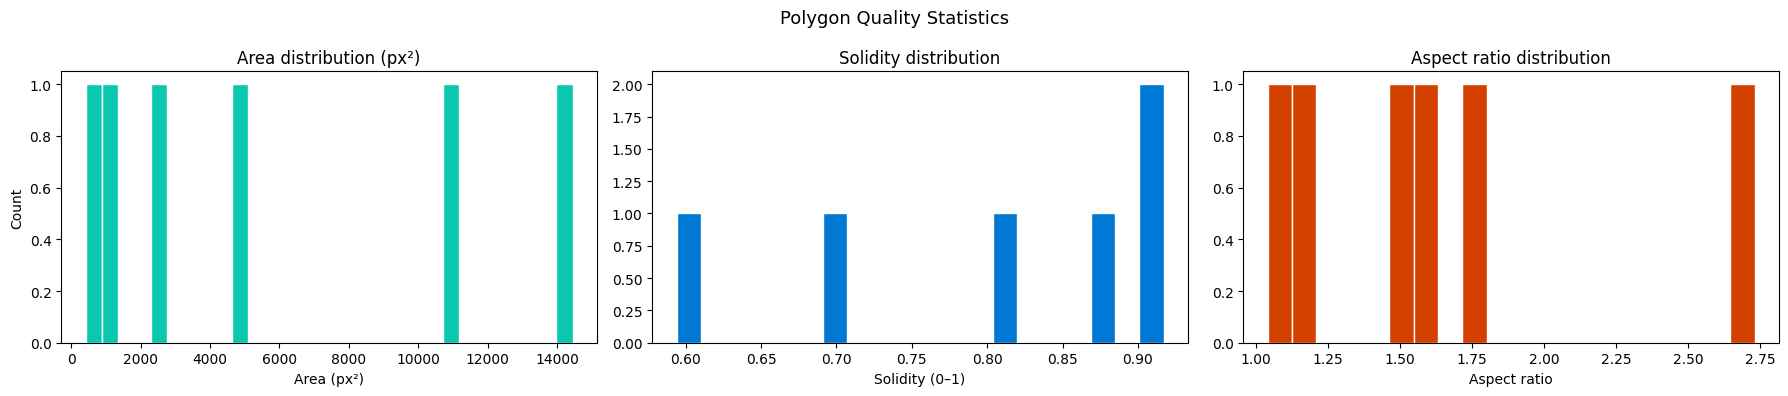

Area    — min: 418  max: 14440  mean: 5726
Solidity — min: 0.59  max: 0.92  mean: 0.80


In [13]:
# ----------------------------------------------------------------
# CELL 7 — Statistics & histogram
# ----------------------------------------------------------------

areas    = [s["area_px"]  for s in stats_list]
solids   = [s["solidity"] for s in stats_list]
aspects  = [s["aspect"]   for s in stats_list]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(areas,   bins=30, color="#0ac8b0", edgecolor="white")
axes[0].set_title("Area distribution (px²)")
axes[0].set_xlabel("Area (px²)")
axes[0].set_ylabel("Count")

axes[1].hist(solids,  bins=20, color="#0078d4", edgecolor="white")
axes[1].set_title("Solidity distribution")
axes[1].set_xlabel("Solidity (0–1)")

axes[2].hist(aspects, bins=20, color="#d44000", edgecolor="white")
axes[2].set_title("Aspect ratio distribution")
axes[2].set_xlabel("Aspect ratio")

plt.suptitle("Polygon Quality Statistics", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "04_statistics.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Area    — min: {min(areas):.0f}  max: {max(areas):.0f}  mean: {np.mean(areas):.0f}")
print(f"Solidity — min: {min(solids):.2f}  max: {max(solids):.2f}  mean: {np.mean(solids):.2f}")

In [14]:
# ----------------------------------------------------------------
# CELL 8 — Build GeoDataFrame & save outputs
# ----------------------------------------------------------------

gdf = gpd.GeoDataFrame(
    {
        "id":        list(range(1, len(polygons) + 1)),
        "area_px":   [s["area_px"]  for s in stats_list],
        "solidity":  [s["solidity"] for s in stats_list],
        "aspect":    [s["aspect"]   for s in stats_list],
        "area_m2":   [round(p.area, 2) for p in polygons],
    },
    geometry=polygons,
    crs=crs,
)

# Reproject to WGS84 for GeoJSON if needed
gdf_wgs84 = gdf.to_crs(epsg=4326) if crs and "4326" not in str(crs) else gdf

# Save all formats
geojson_path = OUTPUT_DIR + "rooftop_polygons.geojson"
shp_path     = OUTPUT_DIR + "rooftop_polygons.shp"
gpkg_path    = OUTPUT_DIR + "rooftop_polygons.gpkg"
csv_path     = OUTPUT_DIR + "rooftop_stats.csv"

gdf_wgs84.to_file(geojson_path, driver="GeoJSON")
gdf.to_file(shp_path)
gdf.to_file(gpkg_path, driver="GPKG")
gdf.drop(columns="geometry").to_csv(csv_path, index=False)

print(f"✅ GeoJSON   → {geojson_path}")
print(f"✅ Shapefile → {shp_path}")
print(f"✅ GeoPackage→ {gpkg_path}")
print(f"✅ CSV stats → {csv_path}")
print(f"\nTotal rooftops saved: {len(gdf)}")
display(gdf.drop(columns="geometry").head(10))

✅ GeoJSON   → /content/drive/MyDrive/Imphal_Rooftop_Project/outputs/rooftop_polygons.geojson
✅ Shapefile → /content/drive/MyDrive/Imphal_Rooftop_Project/outputs/rooftop_polygons.shp
✅ GeoPackage→ /content/drive/MyDrive/Imphal_Rooftop_Project/outputs/rooftop_polygons.gpkg
✅ CSV stats → /content/drive/MyDrive/Imphal_Rooftop_Project/outputs/rooftop_stats.csv

Total rooftops saved: 6


,id,area_px,solidity,aspect,area_m2
0,1,418.0,0.812,1.20,0.0
1,2,4841.5,0.594,2.73,0.0
2,3,14440.0,0.917,1.63,0.0
3,4,1108.0,0.699,1.04,0.0
4,5,2524.5,0.880,1.77,0.0
5,6,11023.5,0.908,1.47,0.0
